In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set()

In [6]:
df = pd.read_csv("superstore_final_dataset (1).csv", encoding='latin1')
df.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680


In [7]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row_ID         9800 non-null   int64  
 1   Order_ID       9800 non-null   object 
 2   Order_Date     9800 non-null   object 
 3   Ship_Date      9800 non-null   object 
 4   Ship_Mode      9800 non-null   object 
 5   Customer_ID    9800 non-null   object 
 6   Customer_Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal_Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product_ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub_Category   9800 non-null   object 
 16  Product_Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

,Row_ID,Postal_Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [9]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True)
df['Ship_Date'] = pd.to_datetime(df['Ship_Date'], dayfirst=True)

In [10]:
df.isnull().sum()

Row_ID            0
Order_ID          0
Order_Date        0
Ship_Date         0
Ship_Mode         0
Customer_ID       0
Customer_Name     0
Segment           0
Country           0
City              0
State             0
Postal_Code      11
Region            0
Product_ID        0
Category          0
Sub_Category      0
Product_Name      0
Sales             0
dtype: int64

In [11]:
df = df.dropna()

In [12]:
df = df.drop_duplicates()

In [13]:
df['Year'] = df['Order_Date'].dt.year
df['Month'] = df['Order_Date'].dt.month
df['Month_Name'] = df['Order_Date'].dt.strftime('%B')

In [14]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

df['Month_Name'] = pd.Categorical(df['Month_Name'], categories=month_order, ordered=True)

In [15]:
total_revenue = df['Sales'].sum()
avg_order_value = df.groupby('Order_ID')['Sales'].sum().mean()
total_orders = df['Order_ID'].nunique()

print("Total Revenue:", total_revenue)
print("Average Order Value:", avg_order_value)
print("Total Orders:", total_orders)

Total Revenue: 2252607.4127
Average Order Value: 458.2195713384866
Total Orders: 4916


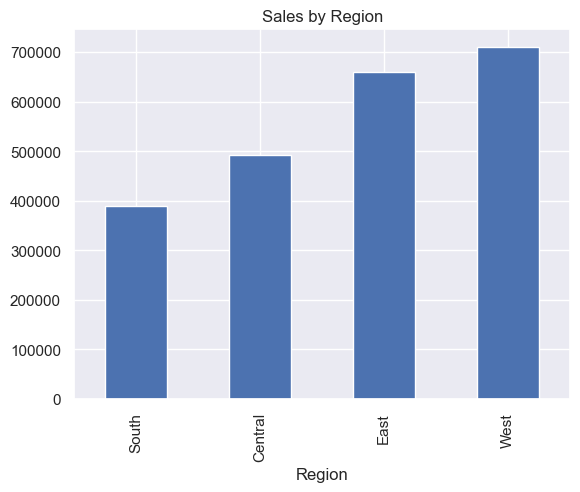

In [16]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values()

region_sales.plot(kind='bar', title='Sales by Region')
plt.show()

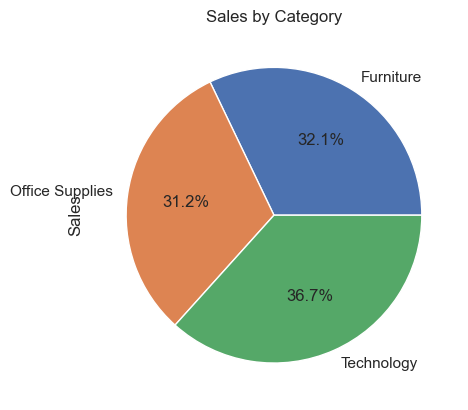

In [17]:
category_sales = df.groupby('Category')['Sales'].sum()

category_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title("Sales by Category")
plt.show()

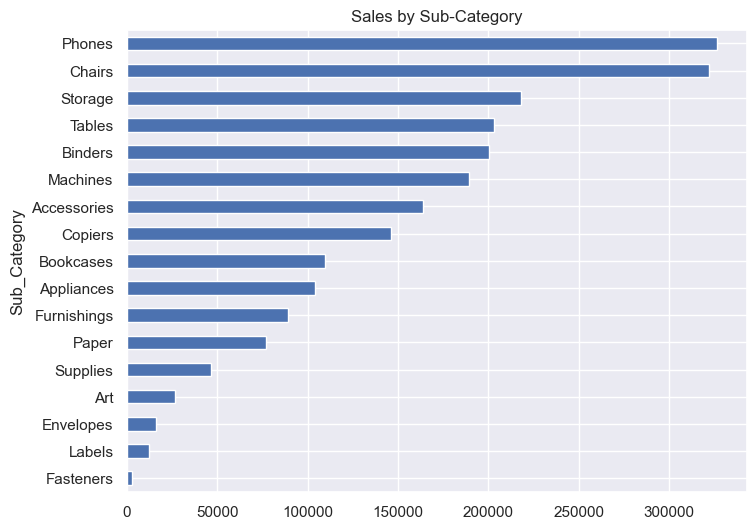

In [18]:
subcat_sales = df.groupby('Sub_Category')['Sales'].sum().sort_values()

subcat_sales.plot(kind='barh', figsize=(8,6))
plt.title("Sales by Sub-Category")
plt.show()

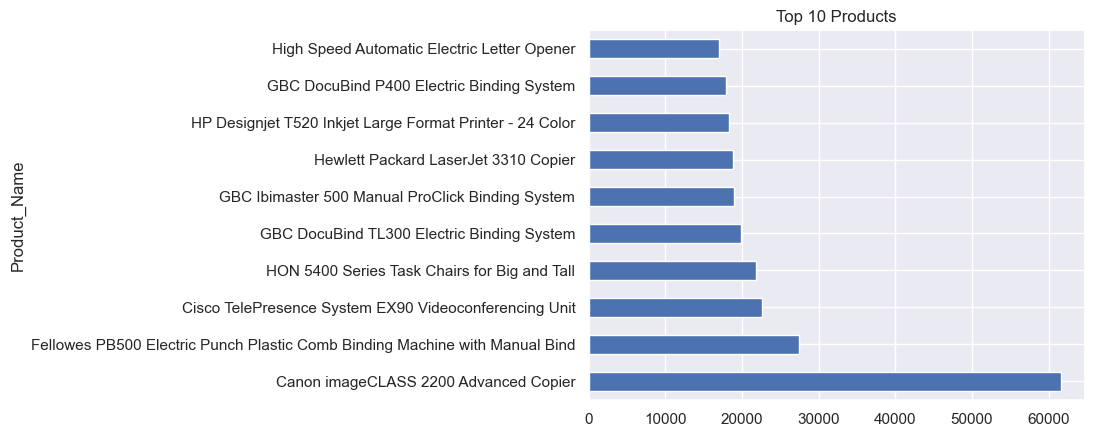

In [19]:
top_products = df.groupby('Product_Name')['Sales'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='barh')
plt.title("Top 10 Products")
plt.show()

In [21]:
worst_products = df.groupby('Product_Name')['Sales'].sum().sort_values().head(10)

C:\Users\shiva\AppData\Local\Temp\ipykernel_22760\4024411788.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_sales = df.groupby('Month_Name')['Sales'].sum()


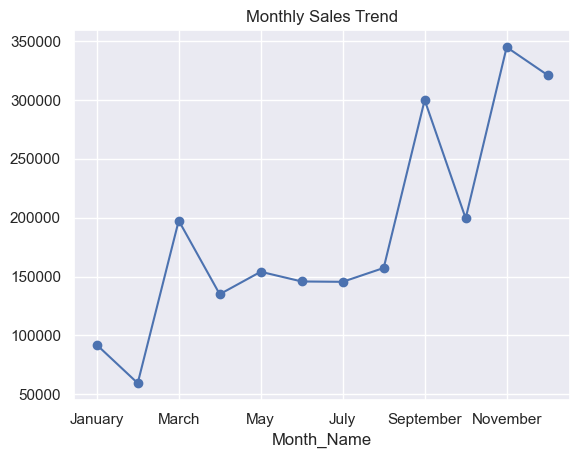

In [22]:
monthly_sales = df.groupby('Month_Name')['Sales'].sum()

monthly_sales.plot(kind='line', marker='o')
plt.title("Monthly Sales Trend")
plt.show()

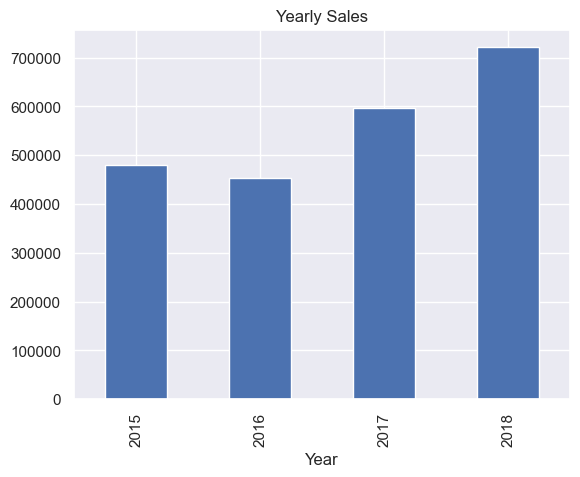

In [23]:
yearly_sales = df.groupby('Year')['Sales'].sum()

yearly_sales.plot(kind='bar')
plt.title("Yearly Sales")
plt.show()

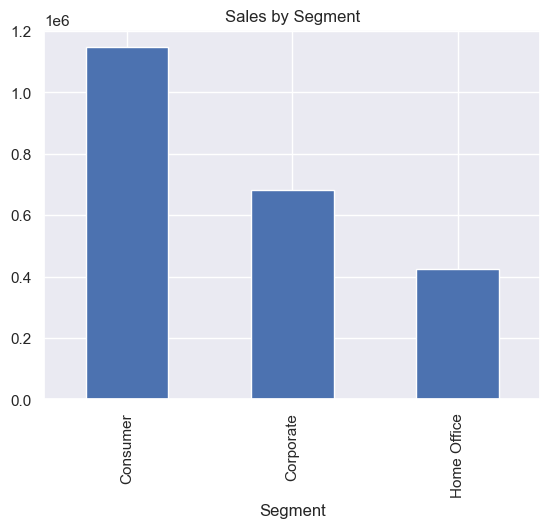

In [24]:
segment_sales = df.groupby('Segment')['Sales'].sum()

segment_sales.plot(kind='bar')
plt.title("Sales by Segment")
plt.show()

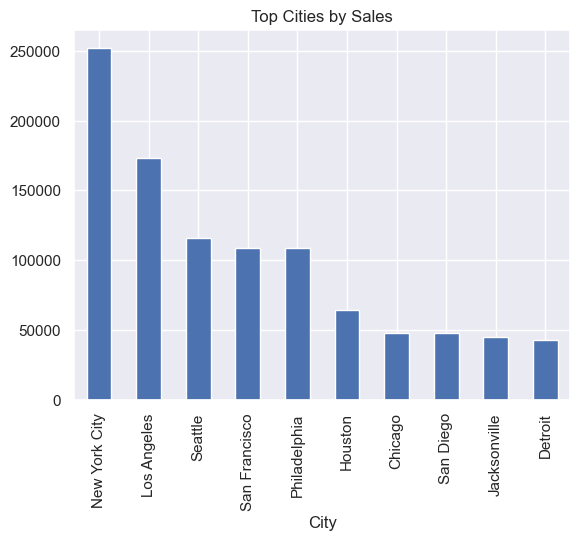

In [25]:
top_cities = df.groupby('City')['Sales'].sum().sort_values(ascending=False).head(10)

top_cities.plot(kind='bar')
plt.title("Top Cities by Sales")
plt.show()

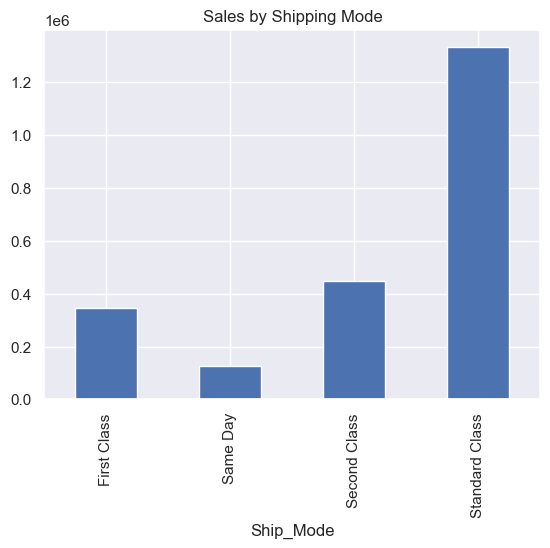

In [26]:
ship_mode_sales = df.groupby('Ship_Mode')['Sales'].sum()

ship_mode_sales.plot(kind='bar')
plt.title("Sales by Shipping Mode")
plt.show()